# SVM para Regressão — Previsão de Preços de Imóveis
**Aluno:** Davi Moraes de Almeida  
**RGM:** 11241100602  
**Curso:** Engenharia de Software — Universidade de Mogi das Cruzes (UMC)

Objetivo: prever o preço mediano dos imóveis (`median_house_value`) com **SVR (Support Vector Regression)** e atingir **R² > 0,65 no conjunto de teste**.

Banco de dados: *Housing* — Kaggle (https://www.kaggle.com/datasets/kathuman/housing). Cada linha é um quarteirão (bloco censitário) da Califórnia.

In [17]:
# Importando as bibliotecas 
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid")

import os
os.makedirs("figs", exist_ok=True)   # cria uma pasta pra guardar os gráficos

ALVO = "median_house_value"   # a coluna que eu quero prever (o preço)
SEED = 42                     # o professor pediu random_state 42

## Etapa 1 — Conhecendo o banco de dados

In [18]:
import glob
caminho = glob.glob("/kaggle/input/**/housing.csv", recursive=True)[0]
print("Arquivo usado:", caminho)

df_original = pd.read_csv(caminho)
df = df_original.copy()

print(df.head())
print("\nDimensões (linhas, colunas):", df.shape)

Arquivo usado: /kaggle/input/datasets/kathuman/housing/housing.csv
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88               41.00       880.00          129.00   
1    -122.22     37.86               21.00     7,099.00        1,106.00   
2    -122.24     37.85               52.00     1,467.00          190.00   
3    -122.25     37.85               52.00     1,274.00          235.00   
4    -122.25     37.85               52.00     1,627.00          280.00   

   population  households  median_income  median_house_value ocean_proximity  
0      322.00      126.00           8.33          452,600.00        NEAR BAY  
1    2,401.00    1,138.00           8.30          358,500.00        NEAR BAY  
2      496.00      177.00           7.26          352,100.00        NEAR BAY  
3      558.00      219.00           5.64          341,300.00        NEAR BAY  
4      565.00      259.00           3.85          342,200.00        NEAR BAY  

Dimensõ

### 3.1 Dimensões e 3.2 Tipos de dados

In [19]:
print("Quantidade de linhas :", df.shape[0])
print("Quantidade de colunas:", df.shape[1])
print()
df.info()

Quantidade de linhas : 20640
Quantidade de colunas: 10

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [20]:
# Separando as colunas pelo tipo de dado
tipos = df.dtypes.astype(str)
print("float  :", list(tipos[tipos.str.contains("float")].index))
print("int    :", list(tipos[tipos.str.contains("int")].index))
print("object/categórica:", list(df.select_dtypes(exclude="number").columns))
print()
print(df["ocean_proximity"].value_counts())

float  : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
int    : []
object/categórica: ['ocean_proximity']

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### 3.3 Estatísticas descritivas

In [21]:
desc = df.describe().T
desc["cv (%)"] = 100 * desc["std"] / desc["mean"].abs()   # CV: mostra o quanto os valores variam em relação à média
desc

,count,mean,std,min,25%,50%,75%,max,cv (%)
longitude,"20,640.00",-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31,1.68
latitude,"20,640.00",35.63,2.14,32.54,33.93,34.26,37.71,41.95,5.99
housing_median_age,"20,640.00",28.64,12.59,1.00,18.00,29.00,37.00,52.00,43.94
total_rooms,"20,640.00","2,635.76","2,181.62",2.00,"1,447.75","2,127.00","3,148.00","39,320.00",82.77
total_bedrooms,"20,433.00",537.87,421.39,1.00,296.00,435.00,647.00,"6,445.00",78.34
population,"20,640.00","1,425.48","1,132.46",3.00,787.00,"1,166.00","1,725.00","35,682.00",79.44
households,"20,640.00",499.54,382.33,1.00,280.00,409.00,605.00,"6,082.00",76.54
median_income,"20,640.00",3.87,1.90,0.50,2.56,3.53,4.74,15.00,49.08
median_house_value,"20,640.00","206,855.82","115,395.62","14,999.00","119,600.00","179,700.00","264,725.00","500,001.00",55.79


In [22]:
# Vendo quantos registros estão no valor máximo 
print("median_house_value = 500.001 :", (df[ALVO] >= 500001).sum(), "registros")
print("housing_median_age = 52      :", (df["housing_median_age"] >= 52).sum(), "registros")
print("median_income      >= 15     :", (df["median_income"] >= 15).sum(), "registros")

median_house_value = 500.001 : 965 registros
housing_median_age = 52      : 1273 registros
median_income      >= 15     : 51 registros


**Interpretação das estatísticas descritivas**

- **Maior dispersão:** o preço (`median_house_value`) tem o maior desvio-padrão absoluto (≈ US$ 115 mil). Em termos relativos (coeficiente de variação), as variáveis de contagem (`total_rooms`, `total_bedrooms`, `population`, `households`) são as mais dispersas, com CV entre 77% e 83%.
- **Valores muito altos:** nas variáveis de contagem o máximo fica muito longe do 3º quartil. `total_rooms` tem Q3 = 3.148 e máximo = 39.320, e `population` tem Q3 = 1.725 e máximo = 35.682. Isso mostra forte assimetria à direita causada por quarteirões muito grandes.
- **Valores estranhos:**
  - O alvo tem máximo exatamente em **500.001**, com 965 registros nesse valor. É um teto de coleta: todo imóvel acima de 500 mil foi registrado como 500.001.
  - `housing_median_age` para em 52, com 1.273 registros no máximo, e `median_income` para em 15, o que indica truncamento semelhante.
  - Também há quarteirões com apenas 1 domicílio ou 2 cômodos no total.
- **Relação com o preço:** `median_income` é a candidata mais forte. A localização (`latitude`, `longitude` e `ocean_proximity`) também deve importar, já que os preços variam bastante entre as categorias de proximidade do oceano.


### 3.4 Valores ausentes

In [23]:
nulos = df.isnull().sum()
print(nulos)
print("\nPercentual de nulos em total_bedrooms: {:.2f}%".format(100 * nulos["total_bedrooms"] / len(df)))
print("Registros duplicados:", df.duplicated().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentual de nulos em total_bedrooms: 1.00%
Registros duplicados: 0


**Decisão:** somente `total_bedrooms` possui valores ausentes (207 registros, cerca de 1% do banco). Os valores serão **preenchidos pela mediana**. A mediana foi escolhida no lugar da média porque a variável tem forte assimetria à direita (média ≈ 538 e máximo 6.445), então a média seria puxada pelos quarteirões muito grandes. Preencher em vez de remover evita descartar 207 quarteirões que têm todas as outras informações completas. Não há registros duplicados.

## Etapa 2 — Análise exploratória

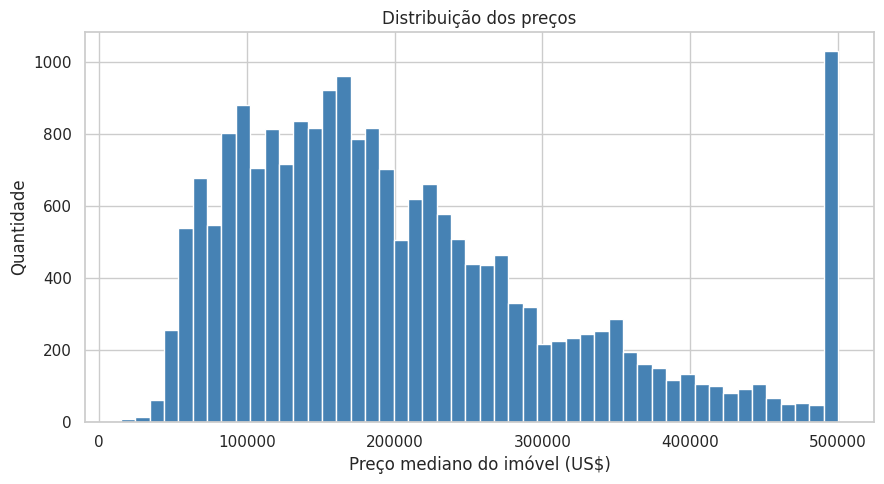

In [24]:
# Gráfico 1: histograma do preço
plt.figure(figsize=(9, 5))
plt.hist(df[ALVO], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Preço mediano do imóvel (US$)")
plt.ylabel("Quantidade")
plt.title("Distribuição dos preços")
plt.tight_layout(); plt.savefig("figs/g1_hist_alvo.png", dpi=130); plt.show()

O histograma mostra uma distribuição **assimétrica à direita**: a maioria dos quarteirões fica entre US$ 100 mil e US$ 250 mil. Há também um **pico artificial em 500.001**, que é o teto da coleta e não uma concentração real de imóveis nesse preço. Essa assimetria motiva, mais adiante, a transformação logarítmica do alvo.

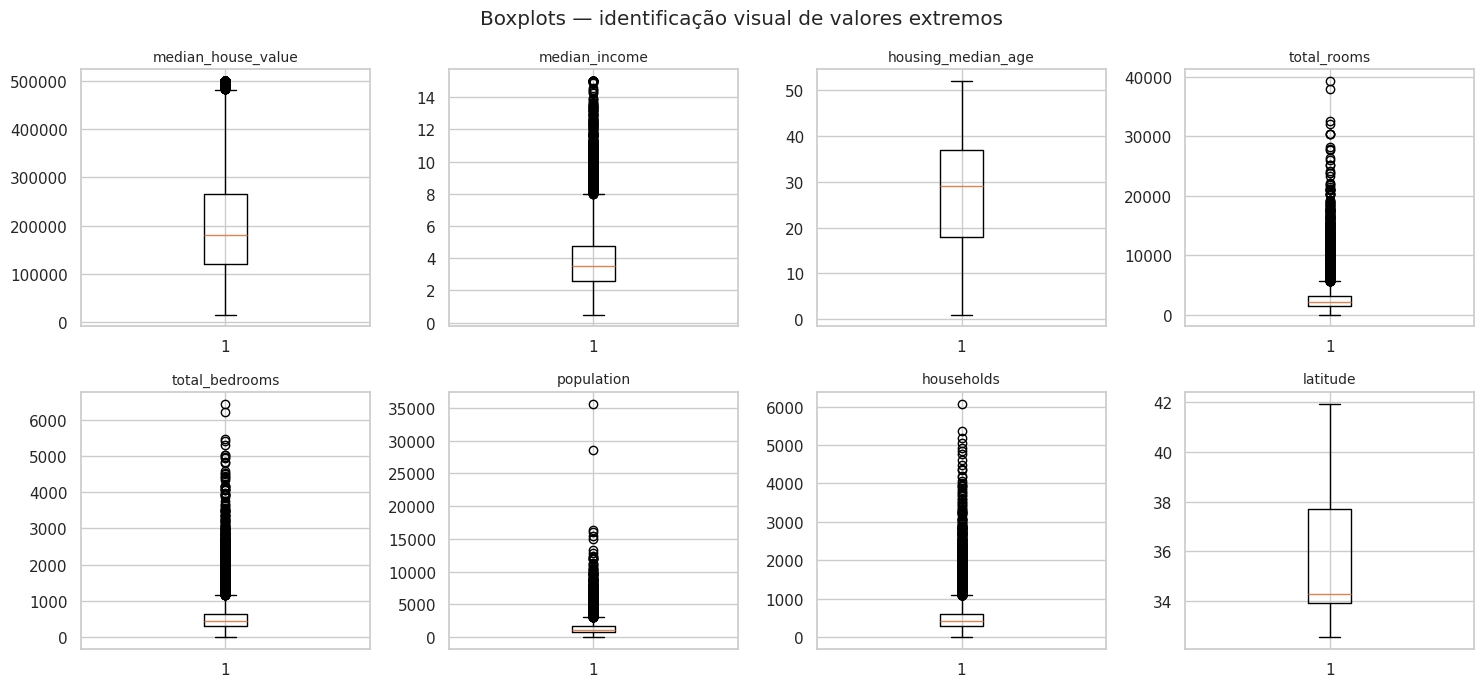

In [25]:
# Gráfico 2: boxplots pra ver os valores extremos
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
cols_box = [ALVO, "median_income", "housing_median_age", "total_rooms",
            "total_bedrooms", "population", "households", "latitude"]
for ax, c in zip(axes.ravel(), cols_box):
    ax.boxplot(df[c].dropna())
    ax.set_title(c, fontsize=10)
plt.suptitle("Boxplots — identificação visual de valores extremos")
plt.tight_layout(); plt.savefig("figs/g2_boxplots.png", dpi=130); plt.show()

Os boxplots confirmam o que o `describe()` indicou:

- As quatro variáveis de contagem têm muitos pontos acima do bigode superior.
- `median_income` tem uma cauda de rendas altas.
- O alvo tem um "bloco" de pontos colado no teto de 500.001.
- `housing_median_age`, `latitude` e `longitude` não apresentam pontos fora dos bigodes.


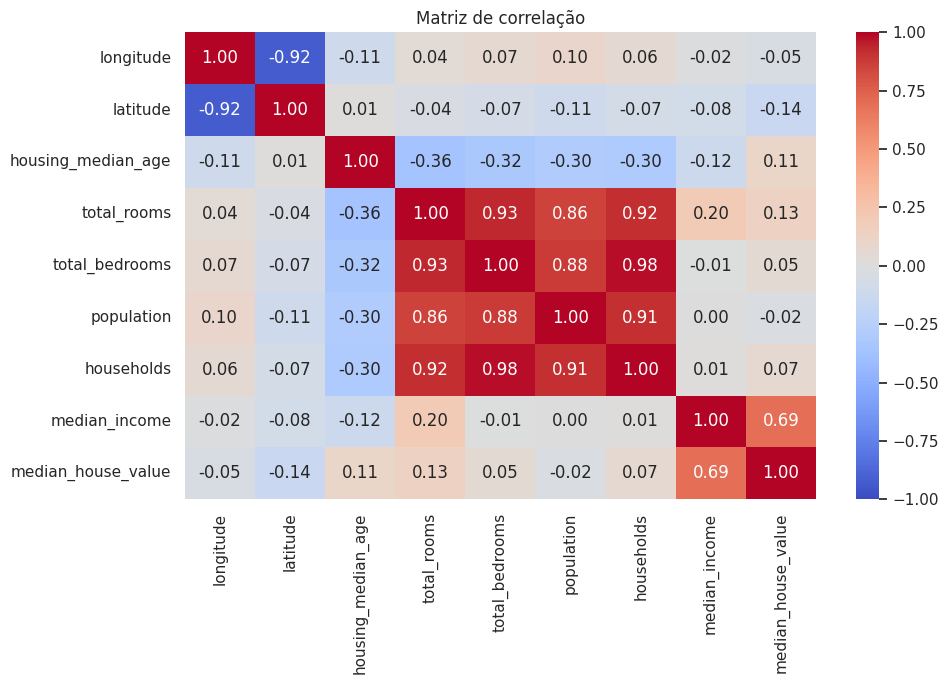

median_house_value    1.00
median_income         0.69
total_rooms           0.13
housing_median_age    0.11
households            0.07
total_bedrooms        0.05
population           -0.02
longitude            -0.05
latitude             -0.14
Name: median_house_value, dtype: float64


In [26]:
# Gráfico 3: correlação entre as variáveis
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.tight_layout(); plt.savefig("figs/g3_correlacao.png", dpi=130); plt.show()

print(df.corr(numeric_only=True)[ALVO].sort_values(ascending=False))

In [27]:
# Preço médio de cada categoria de ocean_proximity
print(df.groupby("ocean_proximity")[ALVO].agg(["count", "mean", "median"]))

                 count       mean     median
ocean_proximity                             
<1H OCEAN         9136 240,084.29 214,850.00
INLAND            6551 124,805.39 108,500.00
ISLAND               5 380,440.00 414,700.00
NEAR BAY          2290 259,212.31 233,800.00
NEAR OCEAN        2658 249,433.98 229,450.00


**Análise da correlação**

- **Mais correlacionada com o preço:** `median_income` (0,69), bem acima de todas as outras.
- **Pouco relacionadas (correlação linear fraca):** `total_rooms` (0,13), `housing_median_age` (0,11), `households`, `total_bedrooms` e `population`, todas com |r| < 0,15. `latitude` (−0,14) e `longitude` (−0,05) também aparecem fracas. Mesmo assim, a localização tem relação **não linear** com o preço: a tabela por `ocean_proximity` mostra que quarteirões INLAND custam cerca de metade dos litorâneos. Esse é um tipo de relação que o kernel RBF consegue capturar.
- **Variáveis redundantes:** `total_rooms`, `total_bedrooms`, `population` e `households` têm correlação muito alta entre si (acima de 0,85), porque todas medem o "tamanho" do quarteirão. `latitude` e `longitude` também são fortemente correlacionadas entre si (−0,92), pelo formato geográfico da Califórnia.


## Etapa 3 — Identificação de outliers (método IQR)

In [28]:
def outliers_iqr(dados, coluna):
    # Acha os outliers de uma coluna usando o método do IQR
    Q1 = dados[coluna].quantile(0.25)
    Q3 = dados[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = dados[(dados[coluna] < limite_inferior) | (dados[coluna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

linhas = []
for col in df.select_dtypes(include="number").columns:
    out, li, ls = outliers_iqr(df, col)
    linhas.append({
        "variável": col,
        "qtd_outliers": len(out),
        "% outliers": 100 * len(out) / df[col].notna().sum(),
        "limite_inferior": li,
        "limite_superior": ls,
        "mínimo": df[col].min(),
        "máximo": df[col].max(),
        "método": "IQR (1,5 × IQR)",
    })
tabela_outliers = pd.DataFrame(linhas)
tabela_outliers

,variável,qtd_outliers,% outliers,limite_inferior,limite_superior,mínimo,máximo,método
0,longitude,0,0.00,-127.48,-112.33,-124.35,-114.31,"IQR (1,5 × IQR)"
1,latitude,0,0.00,28.26,43.38,32.54,41.95,"IQR (1,5 × IQR)"
2,housing_median_age,0,0.00,-10.50,65.50,1.00,52.00,"IQR (1,5 × IQR)"
3,total_rooms,1287,6.24,"-1,102.62","5,698.38",2.00,"39,320.00","IQR (1,5 × IQR)"
4,total_bedrooms,1271,6.22,-230.50,"1,173.50",1.00,"6,445.00","IQR (1,5 × IQR)"
5,population,1196,5.79,-620.00,"3,132.00",3.00,"35,682.00","IQR (1,5 × IQR)"
6,households,1220,5.91,-207.50,"1,092.50",1.00,"6,082.00","IQR (1,5 × IQR)"
7,median_income,681,3.30,-0.71,8.01,0.50,15.00,"IQR (1,5 × IQR)"
8,median_house_value,1071,5.19,"-98,087.50","482,412.50","14,999.00","500,001.00","IQR (1,5 × IQR)"


In [29]:
# Quantos outliers do preço são exatamente 500.001?
out_alvo, li, ls = outliers_iqr(df, ALVO)
print("Outliers do alvo pelo IQR:", len(out_alvo))
print("  - iguais ao teto 500.001:", (out_alvo[ALVO] >= 500001).sum())
print("  - demais (entre o limite e o teto):", (out_alvo[ALVO] < 500001).sum())

Outliers do alvo pelo IQR: 1071
  - iguais ao teto 500.001: 965
  - demais (entre o limite e o teto): 106


**Resumo da identificação (IQR, 1,5 × IQR):**

- **Variáveis com outliers:**
  - `total_rooms`: 1.287 (6,2%)
  - `total_bedrooms`: 1.271 (6,2%)
  - `population`: 1.196 (5,8%)
  - `households`: 1.220 (5,9%)
  - `median_income`: 681 (3,3%)
  - `median_house_value`: 1.071 (5,2%)
- **Sem outliers:** `longitude`, `latitude` e `housing_median_age`.
- **Alvo:** dos 1.071 outliers do alvo, **965 são exatamente o valor de teto** (500.001).


## Etapa 4 — Tratamento dos outliers

Decisões (cada variável foi tratada de acordo com a natureza do valor extremo):

| Variável | Decisão | Justificativa |
|---|---|---|
| `median_house_value` (alvo) | **Remover do treino** apenas os registros com valor = 500.001 | É um **teto artificial** da coleta: o preço real é "500 mil ou mais" e não se sabe o valor verdadeiro. São dados censurados, que ensinariam ao modelo um preço errado. Os outros 106 outliers do IQR (entre 482 mil e 500 mil) são imóveis reais e foram **mantidos**. A remoção é feita **somente no conjunto de treino**: o teste continua completo, inclusive com os imóveis no teto, para que a avaliação represente o uso real do modelo e use o mesmo conjunto de teste de quem não removeu nada. |
| `total_rooms`, `total_bedrooms`, `population`, `households` | **Substituir pelos limites (capping)** | Os extremos são quarteirões realmente grandes (não erro de cadastro), então não faz sentido apagar as linhas. Porém valores até 7× acima do limite distorcem a escala. O capping preserva os registros e reduz a influência desses pontos. Os limites são calculados no treino e aplicados também ao teste. |
| `median_income` | **Manter** | É a variável mais correlacionada com o preço (≈ 0,69). As rendas altas são reais e explicam justamente os imóveis caros; cortá-las prejudicaria o aprendizado. |
| `housing_median_age`, `latitude`, `longitude` | Sem outliers pelo IQR | Nenhum tratamento. |

Com isso, a remoção de dados fica restrita a **786 registros do treino (4,8% do treino, 3,8% do banco)**, sem excluir parte grande dos registros para inflar o R² e sem tocar no conjunto de teste.

## Etapa 5 — Preparação dos dados e experimentos incrementais

Para comparar o efeito de cada tratamento (Etapa 12), foram montadas **versões do banco** com os tratamentos aplicados de forma acumulada.

Para que todas sejam avaliadas nas mesmas condições, a **divisão treino/teste é feita uma única vez, sobre o banco original**, com `train_test_split(test_size=0.20, random_state=42)`. O conjunto de teste (4.128 quarteirões) é **o mesmo para todos os modelos**. A mediana usada na imputação, os limites do IQR e o `StandardScaler` são calculados **somente no treino** e depois aplicados ao teste, sem vazamento de informação.

No baseline (V1), as 207 linhas com `NaN` precisam ser descartadas porque o SVR não as aceita. Por acaso, todas caíram no teste, então o V1 é avaliado em 3.921 quarteirões.

In [30]:
def dividir(X, y):
    # Divide em treino e teste (80/20)
    return train_test_split(X, y, test_size=0.20, random_state=SEED)

def padronizar(X_train, X_test):
    # Padroniza os dados; o fit é feito só no treino
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test), scaler

def avaliar(modelo, X_train, X_test, y_train, y_test):
    # Treina o modelo, prevê no teste e calcula R², MAE e RMSE
    t0 = time.time()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "tempo (s)": time.time() - t0,
    }, y_pred

experimentos = []   # aqui vou guardar o resultado de cada teste
def registrar(nome, tratamento, kernel, C, epsilon, gamma, res):
    experimentos.append({"Experimento": nome, "Tratamento": tratamento, "Kernel": kernel,
                         "C": C, "Epsilon": epsilon, "Gamma": gamma,
                         "R²": res["R2"], "MAE": res["MAE"], "RMSE": res["RMSE"]})
    print(f"{nome:<4} | {tratamento:<45} | R² = {res['R2']:.4f}")

In [31]:
# Primeiro divido o banco em treino e teste, uma vez só.
# Assim todos os modelos são testados nos mesmos dados.
# A mediana, os limites do IQR etc. são calculados só com o treino,
# pra o teste não "vazar" informação pro modelo.
X_full = df_original.drop(ALVO, axis=1)
y_full = df_original[ALVO]
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED)

# Versão 1: sem tratamento nenhum
# O SVR não aceita valor vazio nem texto, então só tiro as linhas vazias
# e uso só as colunas numéricas.
num_cols = X_full.select_dtypes(include="number").columns
ok_tr = X_tr_raw[num_cols].notna().all(axis=1)
ok_te = X_te_raw[num_cols].notna().all(axis=1)
X1_tr, X1_te = X_tr_raw.loc[ok_tr, num_cols], X_te_raw.loc[ok_te, num_cols]
y1_tr, y1_te = y_tr_raw[ok_tr], y_te_raw[ok_te]

# Versão 2: preenchendo os valores vazios e transformando a coluna de texto
mediana_quartos = X_tr_raw["total_bedrooms"].median()          # mediana pega só do treino

def preparar_v2(X):
    X = X.copy()
    X["total_bedrooms"] = X["total_bedrooms"].fillna(mediana_quartos)
    return pd.get_dummies(X, columns=["ocean_proximity"], dtype=int)   # transforma o texto em colunas de 0 e 1

X2_tr = preparar_v2(X_tr_raw)
X2_te = preparar_v2(X_te_raw).reindex(columns=X2_tr.columns, fill_value=0)

# Versão 3: tratando os outliers
# Tiro do treino os imóveis com preço 500.001 (o valor real é desconhecido).
# O teste continua completo.
nao_censurado = y_tr_raw < 500001
X3_tr, y3_tr = X2_tr[nao_censurado].copy(), y_tr_raw[nao_censurado]
X3_te = X2_te.copy()
# Valores muito grandes são "cortados" no limite do IQR (capping)
limites_capping = {}
for col in ["total_rooms", "total_bedrooms", "population", "households"]:
    _, li, ls = outliers_iqr(X3_tr, col)
    limites_capping[col] = (li, ls)
    X3_tr[col] = X3_tr[col].clip(lower=li, upper=ls)
    X3_te[col] = X3_te[col].clip(lower=li, upper=ls)

print(f"Treino: {len(X_tr_raw)} | Teste: {len(X_te_raw)} (o mesmo teste para todos os modelos)")
print(f"V1 — linhas com NaN descartadas: treino {(~ok_tr).sum()}, teste {(~ok_te).sum()}")
print(f"V2 — mediana de total_bedrooms (treino): {mediana_quartos:.0f}")
print(f"V3 — registros com preço = 500.001 removidos do treino: {(~nao_censurado).sum()} "
      f"({100 * (~nao_censurado).mean():.2f}% do treino; {100 * (~nao_censurado).sum() / len(df_original):.2f}% do banco)")
print("Limites do capping (treino):", {k: (round(v[0], 1), round(v[1], 1)) for k, v in limites_capping.items()})
print("Colunas após get_dummies:", list(X2_tr.columns))

Treino: 16512 | Teste: 4128 (o mesmo teste para todos os modelos)
V1 — linhas com NaN descartadas: treino 0, teste 207
V2 — mediana de total_bedrooms (treino): 437
V3 — registros com preço = 500.001 removidos do treino: 786 (4.76% do treino; 3.81% do banco)
Limites do capping (treino): {'total_rooms': (np.float64(-1091.5), np.float64(5672.5)), 'total_bedrooms': (np.float64(-227.0), np.float64(1173.0)), 'population': (np.float64(-621.5), np.float64(3166.5)), 'households': (np.float64(-205.5), np.float64(1094.5))}
Colunas após get_dummies: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## Etapas 6, 7 e 8 — Divisão treino/teste, padronização e modelo baseline

In [32]:
# Modelo 1: SVR padrão nos dados sem tratamento (baseline)
res, _ = avaliar(SVR(), X1_tr, X1_te, y1_tr, y1_te)
registrar("E1", "Dados originais (baseline)", "rbf", 1, 0.1, "scale", res)

# Modelo 2: com os valores vazios preenchidos
res, _ = avaliar(SVR(), X2_tr, X2_te, y_tr_raw, y_te_raw)
registrar("E2", "Valores ausentes (mediana) + dummies", "rbf", 1, 0.1, "scale", res)

# Modelo 3: tratando também os outliers
res, _ = avaliar(SVR(), X3_tr, X3_te, y3_tr, y_te_raw)
registrar("E3", "Ausentes + outliers", "rbf", 1, 0.1, "scale", res)

# Modelo 4: padronizando os dados também
X_train, X_test, y_train, y_test = X3_tr, X3_te, y3_tr, y_te_raw
X_train_s, X_test_s, scaler = padronizar(X_train, X_test)
res, _ = avaliar(SVR(), X_train_s, X_test_s, y_train, y_test)
registrar("E4", "Ausentes + outliers + padronização", "rbf", 1, 0.1, "scale", res)

E1   | Dados originais (baseline)                    | R² = -0.0484
E2   | Valores ausentes (mediana) + dummies          | R² = -0.0487
E3   | Ausentes + outliers                           | R² = -0.0750
E4   | Ausentes + outliers + padronização            | R² = -0.0694


E3   | Ausentes + outliers                           | R² = -0.0750


E4   | Ausentes + outliers + padronização            | R² = -0.0694


**Resultado do baseline:** todos os modelos com `SVR()` padrão ficaram com **R² negativo** (≈ −0,05 a −0,07), ou seja, piores que simplesmente prever a média. Nessa configuração, os tratamentos não ajudam: o R² fica praticamente igual ou piora um pouco.

O problema não está nos dados, e sim na **escala do alvo**. Com `C=1` e `epsilon=0.1`, o SVR tenta ajustar preços na casa das centenas de milhares com uma penalidade muito pequena. O resultado é uma função quase constante, e a padronização de X sozinha não resolve isso. Os modelos 3 e 4 ficam um pouco piores porque o treino deixou de ter os imóveis no teto de 500.001, então essa função quase constante fica ainda mais baixa em relação ao teste, que tem esses imóveis.

## Etapa 9 — Otimização do modelo

### Aumentando o parâmetro C (alvo na escala original)

In [33]:
for i, C in enumerate([10, 100, 1000, 10000], start=5):
    res, _ = avaliar(SVR(kernel="rbf", C=C, epsilon=0.1), X_train_s, X_test_s, y_train, y_test)
    registrar(f"E{i}", "Dados tratados + padronização", "rbf", C, 0.1, "scale", res)

E5   | Dados tratados + padronização                 | R² = -0.0144
E6   | Dados tratados + padronização                 | R² = 0.2653
E7   | Dados tratados + padronização                 | R² = 0.5455
E8   | Dados tratados + padronização                 | R² = 0.6765


E7   | Dados tratados + padronização                 | R² = 0.5455


E8   | Dados tratados + padronização                 | R² = 0.6765


Aumentar C faz o R² subir bastante: −0,01 com C=10, 0,27 com C=100, 0,55 com C=1.000 e **0,68 com C=10.000**, que já passa da meta. Mesmo assim, usar C tão alto só compensa a escala do alvo. Além disso, `epsilon=0.1` em dólares não tem significado prático.

### Transformação da variável alvo (log)
Em vez de usar C gigantesco, a solução mais adequada é colocar o alvo em uma escala compatível com o SVR. Foi aplicado **log** no preço com `TransformedTargetRegressor`: o modelo aprende `log(preço)` e a previsão volta automaticamente para dólares com `exp`. Assim, as métricas continuam sendo calculadas **em dólares, no conjunto de teste**. O log também reduz a assimetria à direita observada no histograma.

In [34]:
def exp_limitado(z):
    # exp com um limite, pra não estourar o número quando o modelo erra feio (ex.: sigmoid)
    return np.exp(np.clip(z, None, np.log(1e7)))

def svr_log(**params):
    # SVR que aprende o log do preço e depois volta pro valor em dólar
    return TransformedTargetRegressor(regressor=SVR(**params), func=np.log,
                                      inverse_func=exp_limitado, check_inverse=False)

res, _ = avaliar(svr_log(kernel="rbf", C=1, epsilon=0.1), X_train_s, X_test_s, y_train, y_test)
registrar("E9", "Tratados + padronização + log(alvo)", "rbf", 1, 0.1, "scale", res)

E9   | Tratados + padronização + log(alvo)           | R² = 0.7298


### 11.1 Testando diferentes kernels

In [35]:
# Testando os 4 kernels com os mesmos dados e parâmetros
resultados_kernel = []
for k in ["linear", "rbf", "poly", "sigmoid"]:
    res, _ = avaliar(svr_log(kernel=k, C=1, epsilon=0.1), X_train_s, X_test_s, y_train, y_test)
    resultados_kernel.append({"Kernel": k, "R²": res["R2"], "MAE": res["MAE"],
                              "RMSE": res["RMSE"], "tempo (s)": res["tempo (s)"]})
tabela_kernels = pd.DataFrame(resultados_kernel)
tabela_kernels.style.format({"R²": "{:.4f}", "MAE": "{:,.0f}", "RMSE": "{:,.0f}", "tempo (s)": "{:.1f}"})

,Kernel,R²,MAE,RMSE,tempo (s)
0,linear,0.0137,"54,815","113,685",26.0
1,rbf,0.7298,"38,659","59,501",7.2
2,poly,0.3167,"42,465","94,626",14.4
3,sigmoid,-3519.8316,"4,839,194","6,792,444",16.1


**Comparação de kernels:**

- **RBF** teve o melhor R² (0,73) e também foi o mais rápido.
- **poly** (grau 3) ficou bem abaixo (0,28). O RMSE alto indica que ele extrapola mal em alguns quarteirões extremos do teste.
- **linear** praticamente não explica o preço (0,01). Ele não captura a relação não linear da localização com o preço e, com o alvo em log, previsões lineares extremas viram erros enormes depois do `exp`.
- **sigmoid** divergiu, com R² muito negativo, e foi descartado.

Por isso, o kernel RBF foi escolhido para a otimização.

## Etapa 10 — Otimização dos hiperparâmetros (GridSearchCV)

O `GridSearchCV` usa **validação cruzada com 5 folds (`cv=5`) sobre todo o conjunto de treino**. O teste fica intocado até o final. Os hiperparâmetros são acessados com o prefixo `regressor__` por causa do `TransformedTargetRegressor`.

O kernel foi fixado em `rbf`, pois foi o melhor na comparação anterior: o `sigmoid` divergiu e o `poly` e o `linear` ficaram muito atrás.

A grade (C ∈ {1, 3, 10}, epsilon ∈ {0,05; 0,1; 0,2}, gamma ∈ {scale; 0,1}) tem 18 combinações × 5 folds = 90 ajustes. Valores de C muito maiores foram deixados de fora por dois motivos: em testes preliminares eles não melhoraram a validação cruzada, e o custo do SVR cresce rapidamente com C, o que tornaria a busca muito lenta. Com `refit=True` (padrão), o melhor modelo é retreinado com todo o treino e só então avaliado no teste.

In [ ]:
parametros = {
    "regressor__C":       [1, 3, 10],
    "regressor__epsilon": [0.05, 0.1, 0.2],
    "regressor__gamma":   ["scale", 0.1],
    "regressor__kernel":  ["rbf"],
}

grid = GridSearchCV(
    svr_log(),
    parametros,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# Procura a melhor combinação usando validação cruzada no treino (o teste fica de fora)
t0 = time.time()
grid.fit(X_train_s, y_train)
tempo_grid = time.time() - t0
print(f"Tempo da busca: {tempo_grid / 60:.1f} min")
print("Melhores parâmetros:", grid.best_params_)
print(f"Melhor R² médio na validação cruzada (treino): {grid.best_score_:.4f}")

In [ ]:
# As 10 melhores combinações
cv = pd.DataFrame(grid.cv_results_)
cv_top = (cv[["param_regressor__C", "param_regressor__epsilon", "param_regressor__gamma",
              "mean_test_score", "std_test_score"]]
          .sort_values("mean_test_score", ascending=False).head(10))
cv_top.columns = ["C", "epsilon", "gamma", "R² médio (CV)", "desvio (CV)"]
cv_top

In [ ]:
# Modelo final: o melhor que o GridSearch achou
params_final = {k.replace("regressor__", ""): v for k, v in grid.best_params_.items()}
modelo_final = grid.best_estimator_
y_pred = modelo_final.predict(X_test_s)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² final (teste): {r2:.4f}")

bp = grid.best_params_
registrar("E10", "Tratados + padronização + log + GridSearch", "rbf",
          bp["regressor__C"], bp["regressor__epsilon"], bp["regressor__gamma"],
          {"R2": r2, "MAE": mae, "RMSE": rmse})

## Etapa 11 — Tabela de experimentos

In [ ]:
tabela_exp = pd.DataFrame(experimentos)
tabela_exp.style.format({"R²": "{:.4f}", "MAE": "{:,.0f}", "RMSE": "{:,.0f}"})

## Etapa 12 — Comparação antes e depois do tratamento

In [ ]:
comparacao = pd.DataFrame([
    ["Baseline (Modelo 1)", "Nenhum",                                   experimentos[0]["R²"]],
    ["Modelo 2",            "Valores ausentes",                         experimentos[1]["R²"]],
    ["Modelo 3",            "Outliers",                                 experimentos[2]["R²"]],
    ["Modelo 4",            "Padronização",                             experimentos[3]["R²"]],
    ["Modelo final",        "Log do alvo + otimização (GridSearch)",    r2],
], columns=["Modelo", "Tratamento (acumulado)", "R² (teste)"])
comparacao.style.format({"R² (teste)": "{:.4f}"})

In [ ]:
plt.figure(figsize=(9, 4.5))
cores = ["#c44e52" if v < 0.65 else "#55a868" for v in comparacao["R² (teste)"]]
plt.bar(comparacao["Modelo"], comparacao["R² (teste)"], color=cores)
plt.axhline(0.65, ls="--", color="black", label="meta R² = 0,65")
plt.ylabel("R² no teste"); plt.title("Evolução do R² com os tratamentos")
plt.xticks(rotation=15); plt.legend()
plt.tight_layout(); plt.savefig("figs/g5_evolucao_r2.png", dpi=130); plt.show()

Os três primeiros tratamentos (valores ausentes, outliers e padronização) **não melhoraram** o R² enquanto o SVR estava com os parâmetros padrão: ele ficou entre −0,05 e −0,07. Eles são necessários (sem eles o SVR nem roda direito), mas **não são suficientes**. O salto veio da **combinação padronização + log do alvo + ajuste de C/epsilon/gamma**, que levou o R² para ≈ 0,74.

## Etapa 13 — Avaliação final

In [ ]:
print("=== Modelo final (conjunto de TESTE) ===")
print(f"R²  : {r2:.4f}")
print(f"MAE : US$ {mae:,.0f}")
print(f"RMSE: US$ {rmse:,.0f}")
print(f"\nPreço médio no teste: US$ {y_test.mean():,.0f}")
print(f"MAE relativo ao preço médio: {100*mae/y_test.mean():.1f}%")

# Comparando treino e teste pra ver se o modelo decorou os dados
r2_treino = r2_score(y_train, modelo_final.predict(X_train_s))
print(f"\nR² treino: {r2_treino:.4f} | R² teste: {r2:.4f}")

## Etapa 14 — Gráfico Real × Predito

In [ ]:
plt.figure(figsize=(8, 6))
lim = [0, 650_000]                      # limita o eixo pra o gráfico não ficar espremido
fora = y_pred > lim[1]                  # previsões muito altas ficam fora do gráfico
plt.scatter(y_test[~fora], y_pred[~fora], alpha=0.3, s=10)
plt.plot(lim, lim, "r--", label="previsão perfeita (y = x)")
plt.xlim(lim); plt.ylim(lim)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Valores reais × valores previstos")
plt.legend()
plt.tight_layout(); plt.savefig("figs/g4_real_predito.png", dpi=130); plt.show()

print(f"Previsões acima de US$ {lim[1]:,} (fora do gráfico): {fora.sum()}")
print(pd.DataFrame({"real": y_test[fora], "previsto": y_pred[fora].round(0)}))

In [ ]:
# Erro médio por faixa de preço (a última faixa é a dos imóveis com 500.001)
faixas = pd.cut(y_test, bins=[0, 100_000, 200_000, 300_000, 400_000, 500_000, 500_001],
                labels=["até 100k", "100k–200k", "200k–300k", "300k–400k", "400k–500k", "teto 500.001"])
erro_faixa = pd.DataFrame({"faixa": faixas, "erro_abs": np.abs(y_test - y_pred), "erro": y_test - y_pred})
print(erro_faixa.groupby("faixa", observed=True).agg(count=("erro_abs", "size"), MAE=("erro_abs", "mean"),
                                                    vies_medio=("erro", "mean")))

**Interpretação do gráfico:**

- A maioria dos pontos está próxima da diagonal vermelha, o que indica boas previsões na faixa de US$ 50 mil a US$ 300 mil.
- A dispersão aumenta para imóveis mais caros: o erro médio vai de ≈ US$ 18 mil (até 100 mil) para ≈ US$ 92 mil (400–500 mil) e ≈ US$ 130 mil no teto de 500.001.
- Nessa faixa cara, o modelo tende a **subestimar** os preços (pontos abaixo da diagonal, viés médio positivo). Há poucos exemplos caros no treino, e as variáveis disponíveis não diferenciam bem um imóvel de 400 mil de um de 500 mil.
- A **coluna vertical em 500.001** são os imóveis censurados que continuam no teste. O valor real deles pode ser bem maior que 500 mil, e o modelo não aprendeu esse teto porque ele foi removido do treino. Esses pontos são os que mais pesam no RMSE.
- Para não achatar o gráfico, o eixo foi limitado em US$ 650 mil. Uma única previsão ficou fora: um quarteirão de Berkeley (NEAR BAY) com renda baixa e muitas pessoas por domicílio, provavelmente moradia estudantil. O preço real é US$ 175 mil e a previsão foi ≈ US$ 995 mil. É um caso atípico em que a extrapolação do modelo em escala log, ao voltar com `exp`, gera um erro grande.

## Desafio extra — Feature engineering

Depois de atingir a meta, foram testadas três variáveis derivadas, calculadas a partir dos valores **originais** (antes do capping): cômodos por domicílio, quartos por cômodo e pessoas por domicílio. Essas razões têm extremos claramente irreais (ex.: mais de 1.000 pessoas por domicílio), então receberam **capping pelo IQR**. O modelo usa os mesmos hiperparâmetros encontrados pelo GridSearch.

In [ ]:
def adicionar_razoes(X):
    X = X.copy()
    X["rooms_per_household"]      = X["total_rooms"] / X["households"]
    X["bedrooms_per_room"]        = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"] / X["households"]
    return X

# Criando as novas colunas a partir dos valores originais
X4_tr = adicionar_razoes(X2_tr[nao_censurado])
X4_te = adicionar_razoes(X2_te)
for col in ["total_rooms", "total_bedrooms", "population", "households",
            "rooms_per_household", "bedrooms_per_room", "population_per_household"]:
    _, li, ls = outliers_iqr(X4_tr, col)            # limites pegos do treino
    X4_tr[col] = X4_tr[col].clip(lower=li, upper=ls)
    X4_te[col] = X4_te[col].clip(lower=li, upper=ls)

Xtr4_s, Xte4_s, _ = padronizar(X4_tr, X4_te)
res_fe, _ = avaliar(svr_log(**params_final), Xtr4_s, Xte4_s, y_train, y_test)
print(f"R² com feature engineering: {res_fe['R2']:.4f}  (modelo final sem FE: {r2:.4f})")
print(f"MAE: {res_fe['MAE']:,.0f} | RMSE: {res_fe['RMSE']:,.0f}")

As variáveis derivadas deram um **ganho muito pequeno**: R² ≈ 0,741 contra 0,738 (+0,003), com RMSE levemente menor e MAE praticamente igual. Esse ganho foi medido no próprio conjunto de teste e é pequeno demais para justificar a troca do modelo escolhido pela validação cruzada. O modelo final foi mantido **sem** feature engineering, por ser mais simples. As razões ficam como uma melhoria possível para trabalhos futuros, a ser confirmada com validação cruzada.

## Conclusão

- **O modelo atingiu R² > 0,65?** Sim. O R² no **conjunto de teste** (completo, com 4.128 quarteirões) foi **≈ 0,738**, com MAE ≈ US$ 37 mil e RMSE ≈ US$ 59 mil.
- **Qual tratamento teve maior impacto?**
  - A **transformação logarítmica do alvo** combinada com a padronização. Sem ela, o SVR padrão teve R² negativo.
  - Em segundo lugar vem o ajuste do parâmetro **C**.
- **O tratamento dos outliers melhorou o resultado?** Isoladamente, não: com o SVR padrão, o R² foi de −0,049 para −0,075. Ele foi mantido por questão metodológica. O capping limita a influência dos quarteirões gigantes, e a remoção dos preços censurados (só do treino) evita ensinar ao modelo um preço que não é o real.
- **Melhor kernel:** **RBF**.
- **Hiperparâmetros finais:** kernel = rbf, C = 10, epsilon = 0,1 (na escala log), gamma = 0,1, com o alvo em log.
- **Dificuldades:**
  - Entender por que o SVR padrão dava R² negativo (escala do alvo).
  - O alto custo computacional do SVR, que limitou o tamanho da grade do GridSearch.
  - O teto artificial no alvo, que continua no teste e é a principal fonte de erro.
- **Como melhorar:**
  - Criar variáveis de localização mais ricas, como distância até grandes cidades ou clusters geográficos.
  - Usar busca aleatória/bayesiana para explorar mais combinações de hiperparâmetros.
  - Tratar o alvo censurado com modelos próprios para censura.
  - Comparar com modelos baseados em árvores (Random Forest, Gradient Boosting), que costumam ir bem nesse banco.